## Problem 1: Chi-Square Goodness-of-Fit Test

Outcome,Observed,Expected
0 Heads,24,30
1 Head,108,90
2 Heads,95,90
3 Heads,23,30



### Hypotheses
- H₀: The coins are fair  
- Hₐ: The coins are not fair  

### Test Statistic
χ² = Σ (O - E)² / E


### Detailed Computation Table

Outcome,Observed,Expected,(O-E)^2 / E
0 Heads,24,30,1.200000
1 Head,108,90,3.600000
2 Heads,95,90,0.277778
3 Heads,23,30,1.633333


...


### Results (Without Yates)
- χ² = 1.3480, p = 0.2456

### Results (With Yates)
- χ² = 0.9627, p = 0.3265

### Decision Rule
Reject H₀ if p < α (0.05 or 0.01)

### Conclusion

Without Yates’ correction:
- At α = 0.05: Fail to reject H₀
- At α = 0.01: Fail to reject H₀

With Yates’ correction:
- At α = 0.05: Fail to reject H₀
- At α = 0.01: Fail to reject H₀

Interpretation:
There is no statistically significant difference between Class A and Class B.


## Problem 3: Coefficient of Contingency

Blonde,Not Blonde
49,25
30,96



### Results
- C (without Yates) = 0.3863  
- C (with Yates) = 0.3779  
- C_max = 0.7071  

### Conclusion
- C = 0.3863, C_max = 0.7071

Since C is substantially lower than C_max,  
there is a **moderate association** between hair color and eye color.


## Problem 4: Regression (mtcars dataset)

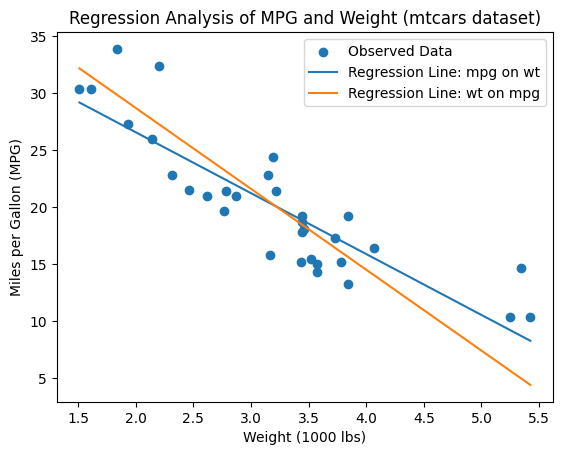


### Interpretation
- mpg on wt slope = -5.3445  

For every 1-unit increase in weight (1000 lbs),  
miles per gallon decreases by approximately 5.3445 mpg.

- wt on mpg slope = -0.1409  

For every 1-unit increase in mpg,  
weight changes by approximately -0.1409 (in 1000 lbs).


## Problem 5: Cars Dataset

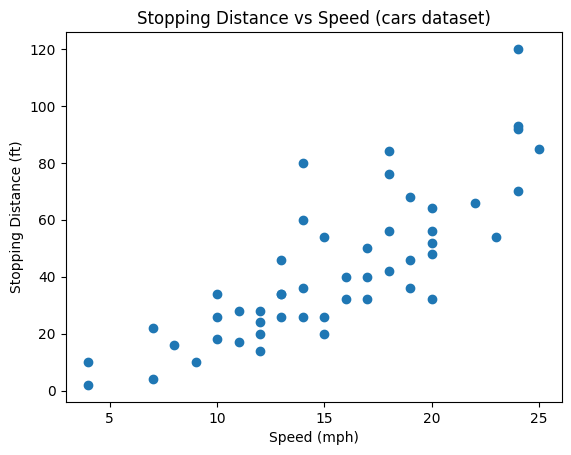

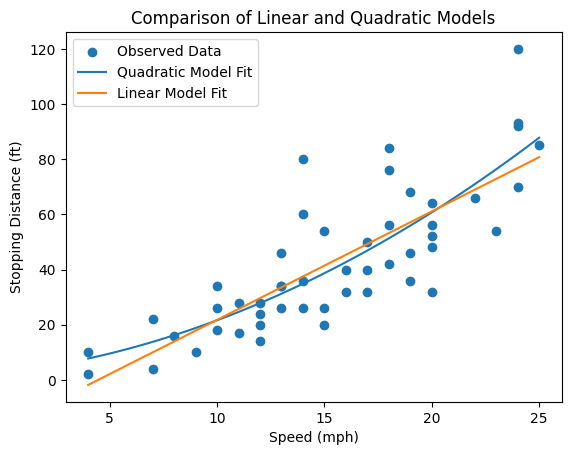


### Predictions
- Distance at 45 mph = 245.99  
- Distance at 80 mph = 715.27  

### Model Comparison
- R² (Linear) = 0.6511  
- R² (Quadratic) = 0.6673  

### Conclusion
The quadratic model provides a better fit because:
- It has a higher R² value, and  
- It captures the nonlinear (curved) relationship between speed and stopping distance,  
which the linear model fails to represent.


In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

# BORJA - APM1111 FA9
# Problem 1: Chi-Square Goodness-of-Fit Test
display(Markdown("## Problem 1: Chi-Square Goodness-of-Fit Test"))

data1 = pd.DataFrame({
    "Outcome": ["0 Heads", "1 Head", "2 Heads", "3 Heads"],
    "Observed": [24,108,95,23],
    "Expected": [30,90,90,30]
})
display(data1.style.hide(axis="index"))

display(Markdown("""
### Hypotheses
- H₀: The coins are fair
- Hₐ: The coins are not fair

### Test Statistic
χ² = Σ (O - E)² / E
"""))

obs = np.array([24,108,95,23])
exp = np.array([30,90,90,30])

# Computation Table
calc_table = pd.DataFrame({
    "Outcome": ["0 Heads", "1 Head", "2 Heads", "3 Heads"],
    "Observed": obs,
    "Expected": exp
})

calc_table["(O-E)^2 / E"] = ((calc_table["Observed"] - calc_table["Expected"])**2) / calc_table["Expected"]

display(Markdown("### Detailed Computation Table"))
display(calc_table.style.hide(axis="index"))

chi2 = calc_table["(O-E)^2 / E"].sum()
df = len(obs)-1
p = 1 - stats.chi2.cdf(chi2, df)

display(Markdown(f"""
### Results
- χ² = {chi2:.4f}
- df = {df}
- p-value = {p:.4f}

### Decision Rule
Reject H₀ if p < 0.05

### Conclusion

At α = 0.05:
- {"Reject H₀" if p < 0.05 else "Fail to reject H₀"}

Interpretation:
There is no sufficient evidence to conclude that the coins are unfair.
"""))

# Problem 2: Chi-Square Test of Independence
display(Markdown("## Problem 2: Chi-Square Test of Independence"))

data2 = pd.DataFrame({
    "Passed": [72,64],
    "Failed": [17,23]
})

display(data2.style.hide(axis="index"))

display(Markdown("""
### Hypotheses
- H₀: No difference between the two classes
- Hₐ: There is a difference between the classes
"""))

obs = np.array([[72,17],[64,23]])

chi2, p, _, _ = stats.chi2_contingency(obs, correction=False)
chi2_y, p_y, _, _ = stats.chi2_contingency(obs, correction=True)

display(Markdown(f"""
### Results (Without Yates)
- χ² = {chi2:.4f}, p = {p:.4f}

### Results (With Yates)
- χ² = {chi2_y:.4f}, p = {p_y:.4f}

### Decision Rule
Reject H₀ if p < α (0.05 or 0.01)

### Conclusion

Without Yates’ correction:
- At α = 0.05: {"Reject H₀" if p < 0.05 else "Fail to reject H₀"}
- At α = 0.01: {"Reject H₀" if p < 0.01 else "Fail to reject H₀"}

With Yates’ correction:
- At α = 0.05: {"Reject H₀" if p_y < 0.05 else "Fail to reject H₀"}
- At α = 0.01: {"Reject H₀" if p_y < 0.01 else "Fail to reject H₀"}

Interpretation:
There is no statistically significant difference between Class A and Class B.
"""))

# Problem 3: Coefficient of Contingency
display(Markdown("## Problem 3: Coefficient of Contingency"))

data3 = pd.DataFrame({
    "Blonde": [49,30],
    "Not Blonde": [25,96]
})

display(data3.style.hide(axis="index"))

obs = np.array([[49,25],[30,96]])
n = np.sum(obs)

chi2, _, _, _ = stats.chi2_contingency(obs, correction=False)
chi2_y, _, _, _ = stats.chi2_contingency(obs, correction=True)

C = np.sqrt(chi2/(chi2+n))
C_y = np.sqrt(chi2_y/(chi2_y+n))

k = min(obs.shape)
Cmax = np.sqrt((k-1)/k)

display(Markdown(f"""
### Results
- C (without Yates) = {C:.4f}
- C (with Yates) = {C_y:.4f}
- C_max = {Cmax:.4f}

### Conclusion
- C = {C:.4f}, C_max = {Cmax:.4f}

Since C is substantially lower than C_max,
there is a **moderate association** between hair color and eye color.
"""))

# Problem 4: Regression (mtcars dataset)
display(Markdown("## Problem 4: Regression (mtcars dataset)"))

mtcars = sm.datasets.get_rdataset("mtcars").data

# Model 1
X = sm.add_constant(mtcars['wt'])
model1 = sm.OLS(mtcars['mpg'], X).fit()

# Model 2
X2 = sm.add_constant(mtcars['mpg'])
model2 = sm.OLS(mtcars['wt'], X2).fit()

# Plot
plt.figure()
plt.scatter(mtcars['wt'], mtcars['mpg'], label="Observed Data")

x_vals = np.linspace(min(mtcars['wt']), max(mtcars['wt']), 100)

y1 = model1.params['const'] + model1.params['wt'] * x_vals
y2 = (x_vals - model2.params['const']) / model2.params['mpg']

plt.plot(x_vals, y1, label="Regression Line: mpg on wt")
plt.plot(x_vals, y2, label="Regression Line: wt on mpg")

plt.title("Regression Analysis of MPG and Weight (mtcars dataset)")
plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Miles per Gallon (MPG)")
plt.legend()
plt.show()

display(Markdown(f"""
### Interpretation
- mpg on wt slope = {model1.params['wt']:.4f}

For every 1-unit increase in weight (1000 lbs),
miles per gallon decreases by approximately {abs(model1.params['wt']):.4f} mpg.

- wt on mpg slope = {model2.params['mpg']:.4f}

For every 1-unit increase in mpg,
weight changes by approximately {model2.params['mpg']:.4f} (in 1000 lbs).
"""))

# Problem 5: Cars Dataset
display(Markdown("## Problem 5: Cars Dataset"))

cars = sm.datasets.get_rdataset("cars").data
V = cars['speed']
D = cars['dist']

# Scatter PLlot
plt.figure()
plt.scatter(V, D)
plt.title("Stopping Distance vs Speed (cars dataset)")
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.show()

# Quadratic (with named columns)
Xq = pd.DataFrame({
    'const': 1,
    'V': V,
    'V2': V**2
})
quad = sm.OLS(D, Xq).fit()

# Linear
Xl = sm.add_constant(V)
lin = sm.OLS(D, Xl).fit()

# Plot
v_vals = np.linspace(min(V), max(V), 100)

d_quad = quad.params['const'] + quad.params['V']*v_vals + quad.params['V2']*v_vals**2
d_lin = lin.params['const'] + lin.params['speed']*v_vals

plt.figure()
plt.scatter(V, D, label="Observed Data")

plt.plot(v_vals, d_quad, label="Quadratic Model Fit")
plt.plot(v_vals, d_lin, label="Linear Model Fit")

plt.title("Comparison of Linear and Quadratic Models")
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.legend()
plt.show()

# Predictions
def predict(v):
    return quad.params['const'] + quad.params['V']*v + quad.params['V2']*v**2

p45 = predict(45)
p80 = predict(80)

display(Markdown(f"""
### Predictions
- Distance at 45 mph = {p45:.2f}
- Distance at 80 mph = {p80:.2f}

### Model Comparison
- R² (Linear) = {lin.rsquared:.4f}
- R² (Quadratic) = {quad.rsquared:.4f}

### Conclusion
The quadratic model provides a better fit because:
- It has a higher R² value, and
- It captures the nonlinear (curved) relationship between speed and stopping distance,
which the linear model fails to represent.
"""))